<div style="background-color: #f0f7ff; padding: 20px; border-radius: 10px; border: 2px solid #007bff;">
    <h1 style="color: #4CAF50; margin-top: 0;">Project 1: Credit Card Default Prediction</h1>
    <p style="font-size: 1.1em;">
        <strong>Dataset Used:</strong> 
        The <a href="https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients">Default of Credit Card Clients</a> dataset from the UCI Machine Learning Repository.
    </p>
    <hr style="border: 0; border-top: 1px solid #007bff;">
    <h3 style="color: #0056b3;">Problem Statement</h3>
    <p style="line-height: 1.6;">
        The goal of this project is to build a binary classification model that predicts whether a client will default on their credit card payment. By analyzing historical behavior and demographics, we aim to help financial institutions identify high-risk borrowers and improve risk management through data-driven decisions.
    </p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# header=1 ensures that the second row is treated as column names 
df = pd.read_excel("default of credit card clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape

(30000, 25)

# Cleaning the Dataset

In [4]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [5]:
# Rename target column to remove spaces for easier reference in code
df.rename(columns={"default payment next month": "default_payment_next_month"}, inplace=True)

# Confirm column names
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_payment_next_month'],
      dtype='object')

In [6]:
# Drop the ID column because it is a unique identifier
# It does not provide predictive value for classification
df.drop(columns=["ID"], inplace=True)

# Check new dataset shape
df.shape

(30000, 24)

The dataset required adjustment because the first row contained descriptive labels rather than actual column headers. The dataset was reloaded using the appropriate header index. The ID column was removed since it does not contribute to prediction and could introduce noise.

In [7]:
# Display dataset information to check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

All features are numerical. No immediate type conversion is required.

In [8]:
# Check for missing values in each column
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64

The dataset contains no missing values, eliminating the need for imputation.

In [9]:
# Count occurrences of each class
df['default_payment_next_month'].value_counts()

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

In [10]:
# Calculate class proportions to evaluate imbalance
df['default_payment_next_month'].value_counts(normalize=True)

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

The dataset is moderately imbalanced, with a higher proportion of non-default cases compared to default cases. This imbalance may influence model performance and evaluation metrics.

In [11]:
# descriptive statistics for numerical features
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Descriptive statistics lets us see feature variability, scale differences, and potential outliers. Significant variation in credit limit and bill amounts suggests that feature scaling will be necessary before model training.

Descriptive statistics reveal large variability in several financial variables.
Average billing amounts (BILL_AMT variables) are approximately $40,000–$50,000, while payment amounts (PAY_AMT variables) average around $4,000–$5,000. However, the maximum values for these features reach hundreds of thousands, indicating the presence of extreme values or outliers.

Because machine learning algorithms such as K-Nearest Neighbors and Support Vector Machines are sensitive to feature scale, feature scaling will be necessary before model training.

In [12]:
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [13]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [14]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [15]:
# EDUCATION contains invalid categories: 0, 5, and 6
# These values represent unknown or undefined education levels
# grouping them into category 4 (Other)

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Verify the updated distribution
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [16]:
# MARRIAGE has a category 0 which represents an undefined status
# grouping this into category 3 (Other)

df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Verify the updated distribution
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

After cleaning, categorical variables now contain only valid and interpretable categories. Grouping rare or undefined values prevents models from learning patterns from categories with extremely small sample sizes.

# Exploratory Data Analysis (EDA)

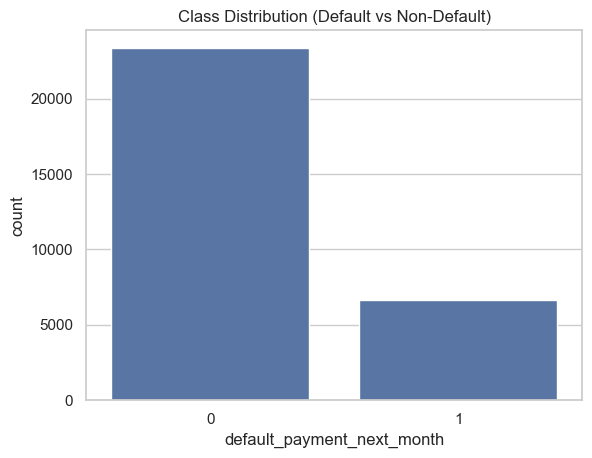

In [17]:
sns.set(style="whitegrid")

sns.countplot(x='default_payment_next_month', data=df)

plt.title("Class Distribution (Default vs Non-Default)")

plt.show()

The class distribution confirms that the dataset is imbalanced, with significantly more non-default cases than default cases. This imbalance must be considered when evaluating model performance.

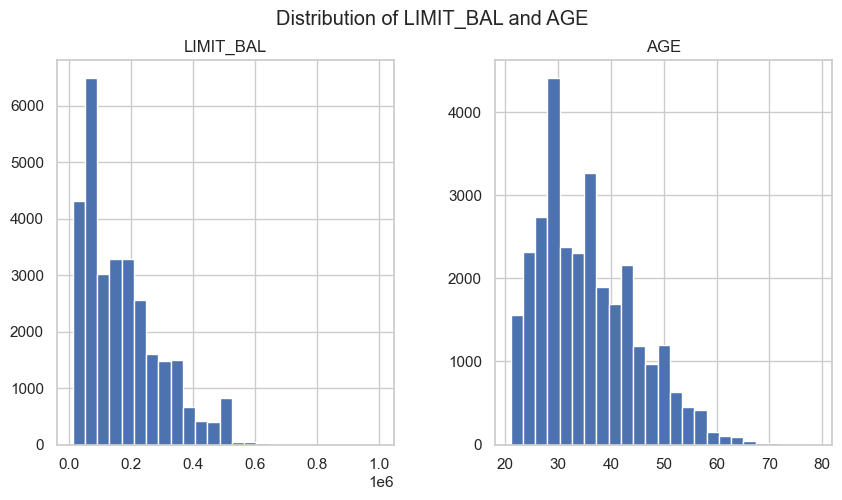

In [18]:
# Plot histograms for key numerical features
df[['LIMIT_BAL', 'AGE']].hist(bins=25, figsize=(10,5))

plt.suptitle("Distribution of LIMIT_BAL and AGE")
plt.show()

NameError: name 'mtick' is not defined

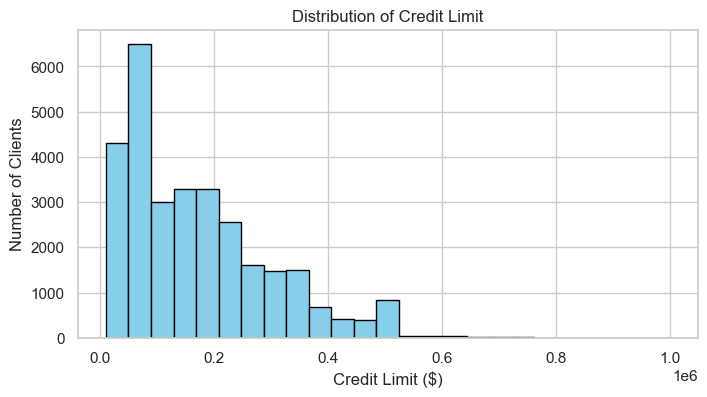

In [19]:
# import matplotlib.ticker as mtick
fig, ax1 = plt.subplots(figsize=(8, 4))
df['LIMIT_BAL'].hist(bins=25, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title("Distribution of Credit Limit")
ax1.set_xlabel("Credit Limit ($)")
ax1.set_ylabel("Number of Clients")
# Format axis to remove scientific notation
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()